# FAO-56 Penman-Monteith — Visualización y Rol en MILPÍN

**Propósito:** Entender qué calcula FAO-56, cómo cada componente afecta el resultado,  
y por qué es el núcleo de las decisiones de riego en el sistema MILPÍN.

**Referencia:**  
Allen, R.G., Pereira, L.S., Raes, D., Smith, M. (1998).  
*Crop evapotranspiration — Guidelines for computing crop water requirements.*  
FAO Irrigation and Drainage Paper 56. Rome, FAO.

---

## Contexto geográfico
- **Sitio:** Valle del Yaqui, Sonora — Distrito de Riego DR-041, Módulo 3  
- **Latitud:** 27.37°N | **Altitud:** 40 m.s.n.m. (Cd. Obregón)  
- **Clima:** Semiárido con veranos muy calurosos (Tmax ≈ 40°C) e inviernos suaves

## Jerarquía de cálculo en MILPÍN

```
Datos NASA POWER (clima_diario)
        │
        ▼
  ETo Penman-Monteith  ─── fallback ──▶  Hargreaves-Samani
        │
        ▼
  ETc = ETo × Kc(cultivo, día_ciclo)   ◀── KC_TABLE / cultivos_catalogo (BD)
        │
        ▼
  Balance Hídrico Diario
  θ[t] = θ[t-1] + (lluvia - ETc) / (Zr × 10)
        │
        ▼
  Decisión: ¿θ < umbral?  ──▶  Recomendación de riego
        │
        ▼
  Lámina bruta = Lámina_neta / 0.75  (eficiencia 75%)
        │
        ▼
  Costo CFE-9CU = Volumen × Tarifa (MXN/m³)
```

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


In [11]:
import sys
import os

# Agregar backend al path para importar balance_hidrico directamente
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator

# Importar motor FAO-56 de MILPÍN
from backend.core.balance_hidrico import (
    calcular_eto_penman_monteith,
    calcular_eto_hargreaves,
    obtener_kc,
    calcular_balance_hidrico,
    calcular_costo_riego,
    KC_TABLE,
    _radiacion_extraterrestre,
    _presion_saturacion,
    _pendiente_curva_saturacion,
)

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Paleta MILPÍN
COLORS = {
    'maiz':    '#f5a623',
    'frijol':  '#8b5e3c',
    'algodon': '#7ec8e3',
    'uva':     '#7b2d8b',
    'chile':   '#d0021b',
    'eto':     '#2196F3',
    'hargreaves': '#FF9800',
    'etc':     '#4CAF50',
    'deficit': '#F44336',
    'lluvia':  '#03A9F4',
    'humedad': '#8BC34A',
}

print('✓ Imports OK — motor FAO-56 cargado desde backend/core/balance_hidrico.py')

✓ Imports OK — motor FAO-56 cargado desde backend/core/balance_hidrico.py


---
## 1. La ecuación Penman-Monteith (FAO-56 Ec. 6)

$$
ET_0 = \frac{0.408\,\Delta\,(R_n - G) + \gamma\,\frac{900}{T+273}\,u_2\,(e_s - e_a)}{\Delta + \gamma\,(1 + 0.34\,u_2)}
$$

| Símbolo | Descripción | Unidad |
|---------|-------------|--------|
| $R_n$   | Radiación neta en la superficie del cultivo | MJ/m²/día |
| $G$     | Flujo de calor del suelo (≈ 0 diario) | MJ/m²/día |
| $T$     | Temperatura media del aire a 2m | °C |
| $u_2$   | Velocidad del viento a 2m | m/s |
| $e_s$   | Presión de vapor de saturación | kPa |
| $e_a$   | Presión de vapor real | kPa |
| $\Delta$ | Pendiente de la curva de saturación | kPa/°C |
| $\gamma$ | Constante psicrométrica | kPa/°C |

ETo base (verano, Valle del Yaqui): 7.60 mm/día


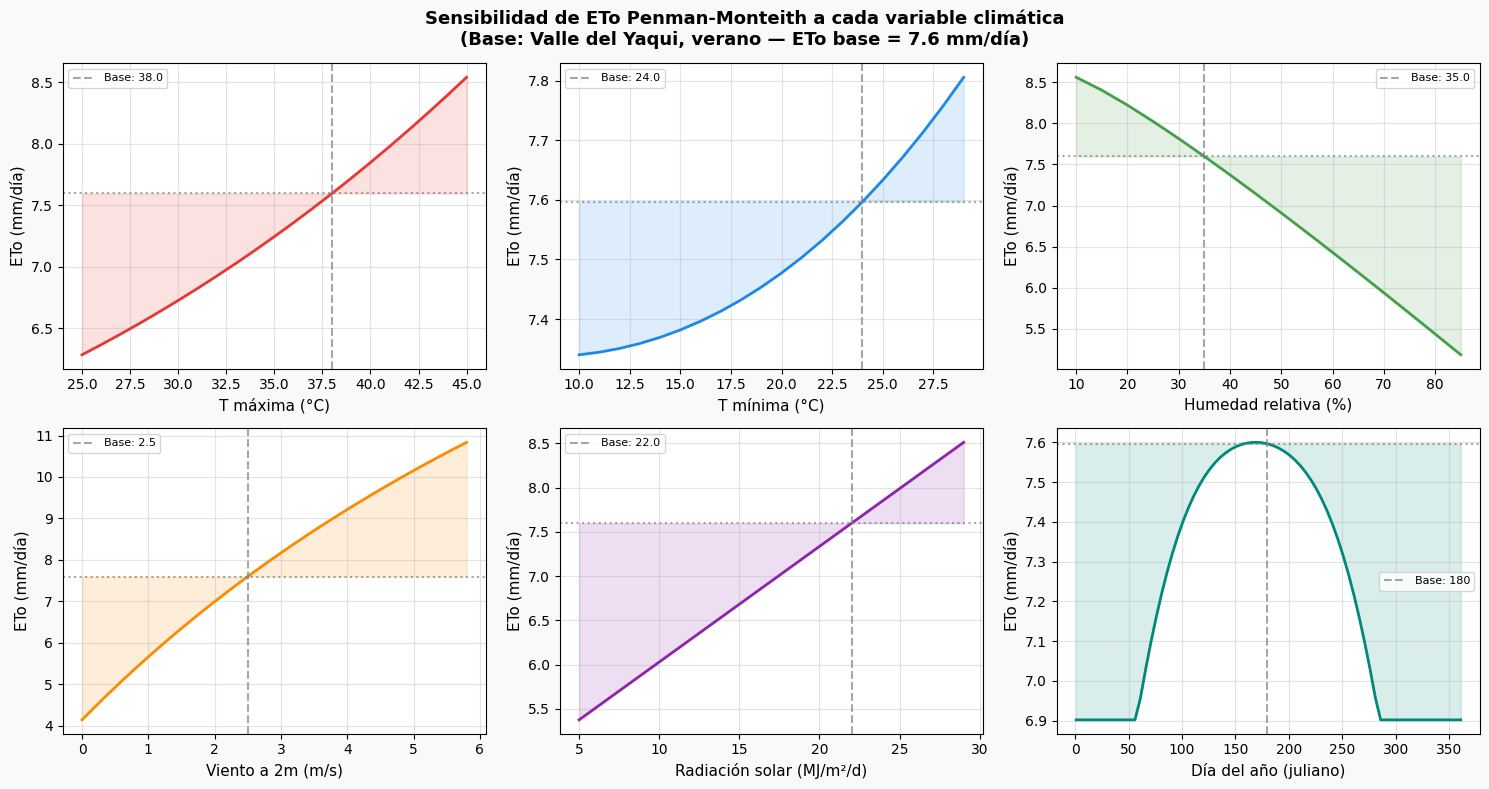

► Guardado: fao56_sensibilidad_eto.png


In [12]:
# ─── 1a. Sensibilidad de ETo a cada variable climática ───────────────────────
#
# Condiciones base: día típico de verano en Valle del Yaqui
BASE = dict(
    tmax=38.0, tmin=24.0, humedad_rel=35.0,
    viento_ms=2.5, radiacion_solar_mj=22.0,
    latitud=27.37, altitud=40.0, dia_del_ano=180,
)

eto_base = calcular_eto_penman_monteith(**BASE)
print(f'ETo base (verano, Valle del Yaqui): {eto_base:.2f} mm/día')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sensibilidad de ETo Penman-Monteith a cada variable climática\n'
             f'(Base: Valle del Yaqui, verano — ETo base = {eto_base:.1f} mm/día)',
             fontsize=13, weight='bold')

variables = [
    ('tmax',             np.arange(25, 46, 1),  'T máxima (°C)',           '#e53935'),
    ('tmin',             np.arange(10, 30, 1),  'T mínima (°C)',           '#1e88e5'),
    ('humedad_rel',      np.arange(10, 90, 5),  'Humedad relativa (%)',    '#43a047'),
    ('viento_ms',        np.arange(0, 6, 0.2),  'Viento a 2m (m/s)',       '#fb8c00'),
    ('radiacion_solar_mj', np.arange(5, 30, 1), 'Radiación solar (MJ/m²/d)', '#8e24aa'),
    ('dia_del_ano',      np.arange(1, 366, 5),  'Día del año (juliano)',    '#00897b'),
]

for ax, (var, vals, label, color) in zip(axes.flat, variables):
    etos = []
    for v in vals:
        params = BASE.copy()
        params[var] = v
        etos.append(calcular_eto_penman_monteith(**params))
    ax.plot(vals, etos, color=color, linewidth=2)
    ax.axvline(BASE[var], color='gray', linestyle='--', alpha=0.7, label=f'Base: {BASE[var]}')
    ax.axhline(eto_base, color='gray', linestyle=':', alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('ETo (mm/día)')
    ax.legend(fontsize=8)
    ax.fill_between(vals, eto_base, etos, alpha=0.15, color=color)

plt.tight_layout()
plt.savefig('fao56_sensibilidad_eto.png', dpi=150, bbox_inches='tight')
plt.show()
print('► Guardado: fao56_sensibilidad_eto.png')

---
## 2. Radiación extraterrestre anual en Valle del Yaqui (27.37°N)

La radiación extraterrestre $R_a$ es el *techo* físico de energía disponible.  
Su variación estacional explica por qué el riego aumenta en verano.

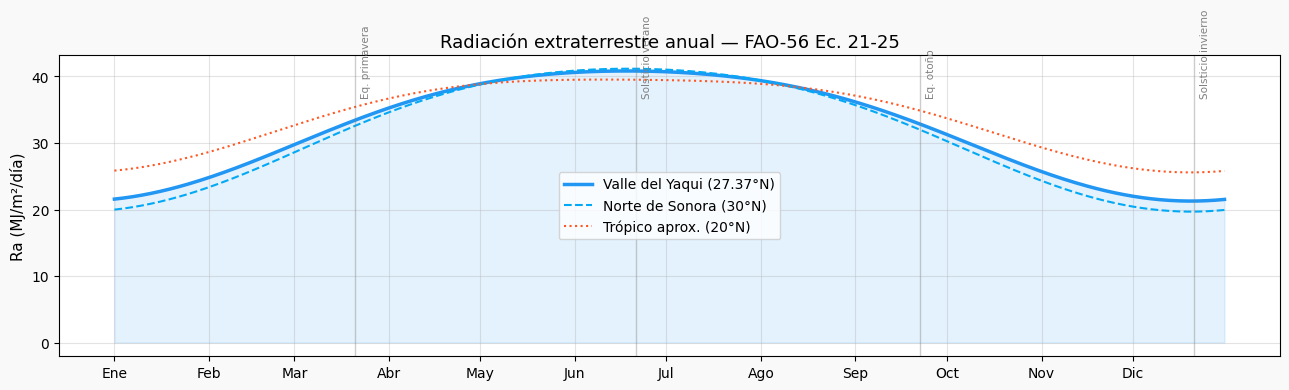

In [13]:
dias = np.arange(1, 366)
ra_yaqui   = np.array([_radiacion_extraterrestre(27.37, d) for d in dias])
ra_sonora_n = np.array([_radiacion_extraterrestre(30.0, d) for d in dias])  # norte Sonora
ra_tropical = np.array([_radiacion_extraterrestre(20.0, d) for d in dias])  # trópico

meses_inicio = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dias, ra_yaqui,    label='Valle del Yaqui (27.37°N)', lw=2.5, color='#2196F3')
ax.plot(dias, ra_sonora_n, label='Norte de Sonora (30°N)',    lw=1.5, color='#03A9F4', ls='--')
ax.plot(dias, ra_tropical, label='Trópico aprox. (20°N)',     lw=1.5, color='#FF5722', ls=':')
ax.fill_between(dias, ra_yaqui, alpha=0.12, color='#2196F3')

# Marcar solsticios y equinoccios
for dia, etiqueta in [(80, 'Eq. primavera'), (172, 'Solsticio verano'),
                       (265, 'Eq. otoño'),   (355, 'Solsticio invierno')]:
    ax.axvline(dia, color='gray', alpha=0.4, lw=1)
    ax.text(dia+2, 37, etiqueta, fontsize=7.5, color='gray', rotation=90)

ax.set_xticks(meses_inicio)
ax.set_xticklabels(meses_labels)
ax.set_ylabel('Ra (MJ/m²/día)')
ax.set_title('Radiación extraterrestre anual — FAO-56 Ec. 21-25')
ax.legend()
plt.tight_layout()
plt.savefig('fao56_ra_anual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. ETo estacional — Penman-Monteith vs Hargreaves-Samani

**Penman-Monteith** es el estándar FAO-56 (requiere T, HR, viento, Rs).  
**Hargreaves-Samani** es el fallback cuando faltan datos (solo T y Ra).

MILPÍN usa Hargreaves automáticamente cuando un registro de `clima_diario`  
no tiene `humedad_rel`, `viento` o `radiacion`.

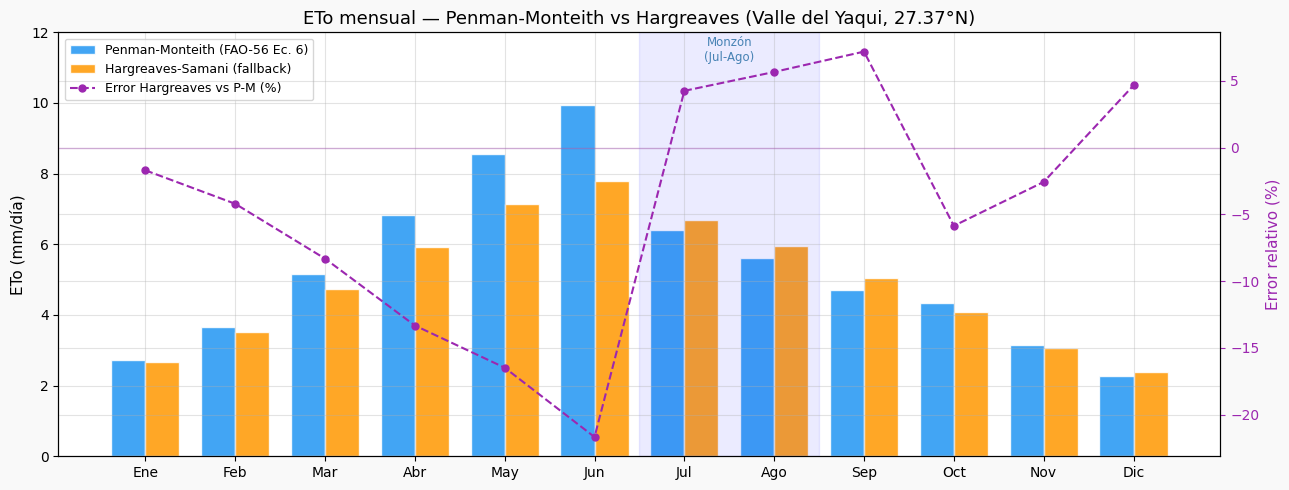

ETo anual estimada (P-M):   1.93 m³/m² ≈ 1926 mm/año
ETo anual estimada (Harg):  1.79 m³/m² ≈ 1793 mm/año


In [14]:
# Clima sintético estacional — Valle del Yaqui (doce meses)
clima_mensual = [
    #  mes  tmax  tmin   hr    u2    Rs
    ('Ene', 22.5, 8.0,  56.0, 2.0, 14.0),
    ('Feb', 25.0, 9.5,  50.0, 2.2, 16.5),
    ('Mar', 28.5, 12.0, 42.0, 2.5, 20.0),
    ('Abr', 32.0, 15.5, 35.0, 2.8, 23.5),
    ('May', 36.5, 19.0, 28.0, 3.0, 26.0),
    ('Jun', 40.0, 23.0, 25.0, 3.2, 28.0),
    ('Jul', 38.5, 26.0, 55.0, 2.0, 22.0),  # monzón
    ('Ago', 37.0, 25.5, 60.0, 1.8, 20.5),  # monzón
    ('Sep', 34.0, 22.0, 58.0, 1.5, 19.0),
    ('Oct', 30.0, 16.0, 48.0, 2.0, 17.0),
    ('Nov', 25.5, 10.5, 52.0, 2.0, 13.5),
    ('Dic', 21.0, 7.0,  58.0, 1.8, 12.0),
]

dias_medios = [15, 46, 75, 106, 136, 167, 197, 228, 259, 289, 320, 350]

meses = [r[0] for r in clima_mensual]
eto_pm   = []
eto_harg = []

for (mes, tmax, tmin, hr, u2, rs), doy in zip(clima_mensual, dias_medios):
    eto_pm.append(calcular_eto_penman_monteith(
        tmax=tmax, tmin=tmin, humedad_rel=hr,
        viento_ms=u2, radiacion_solar_mj=rs,
        latitud=27.37, altitud=40.0, dia_del_ano=doy
    ))
    eto_harg.append(calcular_eto_hargreaves(
        tmax=tmax, tmin=tmin, latitud=27.37, dia_del_ano=doy
    ))

x = np.arange(12)
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, eto_pm,   width, label='Penman-Monteith (FAO-56 Ec. 6)',
               color=COLORS['eto'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, eto_harg, width, label='Hargreaves-Samani (fallback)',
               color=COLORS['hargreaves'], alpha=0.85, edgecolor='white')

# Error relativo
ax2 = ax.twinx()
err = [(h - p) / max(p, 0.01) * 100 for p, h in zip(eto_pm, eto_harg)]
ax2.plot(x, err, 'o--', color='#9C27B0', lw=1.5, ms=5, label='Error Hargreaves vs P-M (%)')
ax2.axhline(0, color='#9C27B0', alpha=0.3, lw=1)
ax2.set_ylabel('Error relativo (%)', color='#9C27B0')
ax2.tick_params(axis='y', colors='#9C27B0')

ax.set_xticks(x)
ax.set_xticklabels(meses)
ax.set_ylabel('ETo (mm/día)')
ax.set_title('ETo mensual — Penman-Monteith vs Hargreaves (Valle del Yaqui, 27.37°N)')
ax.set_ylim(0, 12)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Anotar período monzón
ax.axvspan(5.5, 7.5, alpha=0.08, color='blue', label='_Monzón')
ax.text(6.5, 11.2, 'Monzón\n(Jul-Ago)', ha='center', fontsize=8.5, color='steelblue')

plt.tight_layout()
plt.savefig('fao56_eto_estacional.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ETo anual estimada (P-M):   {sum(eto_pm)*30.4/1000:.2f} m³/m² ≈ {sum(eto_pm)*30.4:.0f} mm/año")
print(f"ETo anual estimada (Harg):  {sum(eto_harg)*30.4/1000:.2f} m³/m² ≈ {sum(eto_harg)*30.4:.0f} mm/año")

---
## 4. Curvas Kc — Los 5 cultivos del DR-041 (KC_TABLE FAO-56)

El **coeficiente de cultivo Kc** convierte ETo en ETc (demanda real del cultivo):  
$ET_c = ET_0 \times K_c$

Cada cultivo tiene 4 etapas fenológicas: **inicial → desarrollo → mediados → final**.

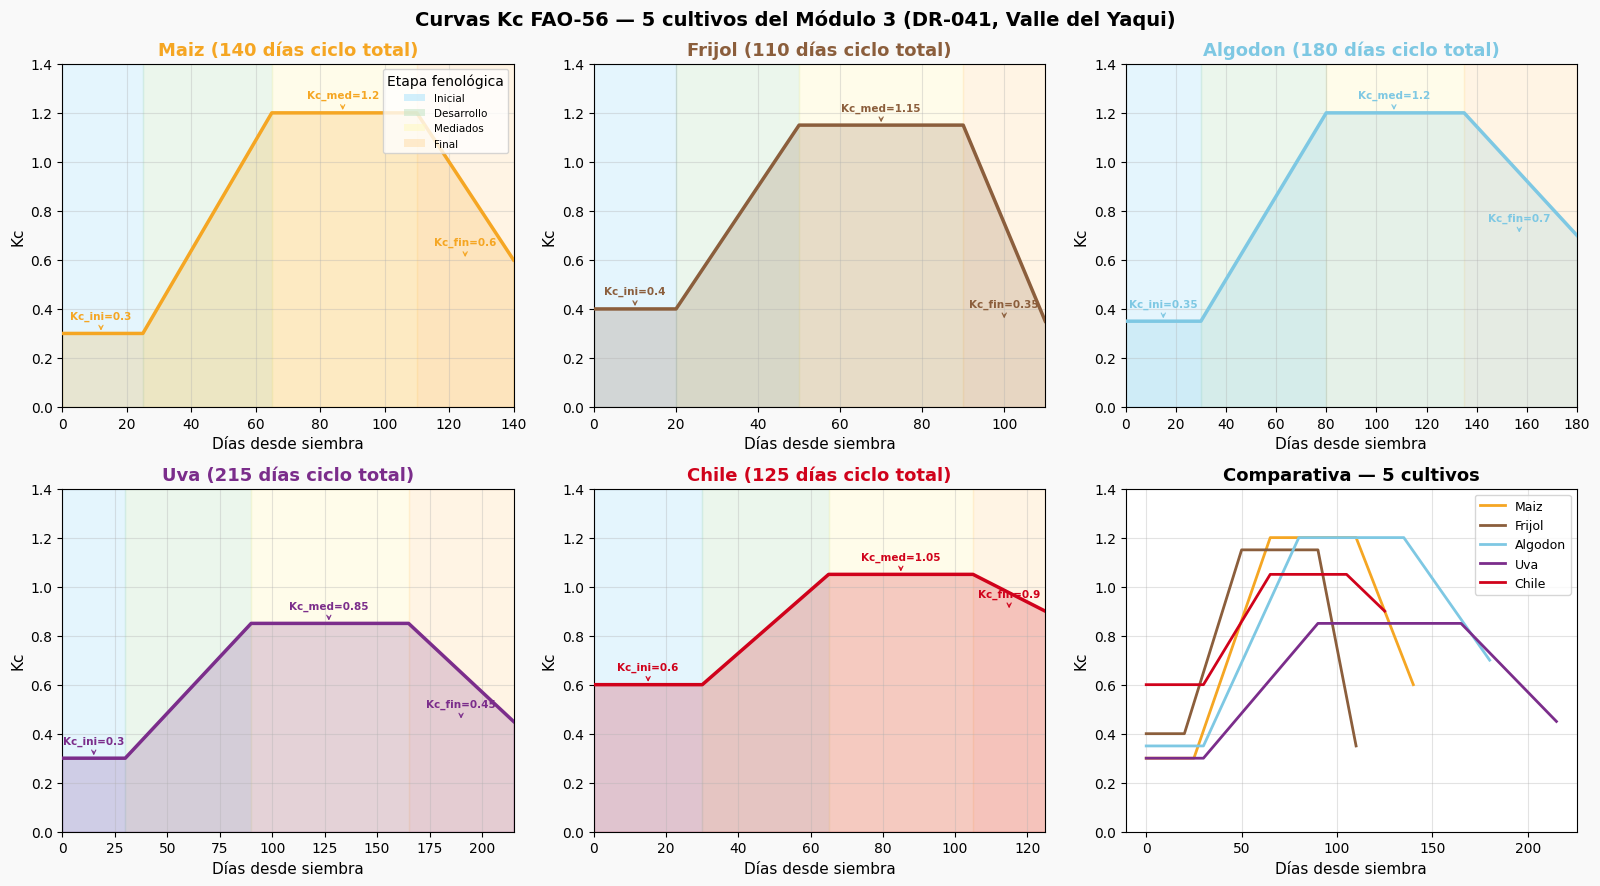

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Curvas Kc FAO-56 — 5 cultivos del Módulo 3 (DR-041, Valle del Yaqui)',
             fontsize=14, weight='bold')

ETAPAS_COLORES = ['#B3E5FC', '#C8E6C9', '#FFF9C4', '#FFE0B2']
ETAPAS_NOMBRES = ['Inicial', 'Desarrollo', 'Mediados', 'Final']

cultivos = list(KC_TABLE.keys())

for idx, (cultivo, ax) in enumerate(zip(cultivos, axes.flat)):
    info = KC_TABLE[cultivo]
    d_ini, d_des, d_med, d_fin = info['duracion_etapas']
    kc_ini, kc_med, kc_fin = info['kc']
    ciclo = d_ini + d_des + d_med + d_fin
    dias = np.arange(0, ciclo + 1)
    kcs  = [obtener_kc(cultivo, d) for d in dias]

    # Sombreado por etapa
    limites = [0, d_ini, d_ini+d_des, d_ini+d_des+d_med, ciclo]
    for i, (ini_e, fin_e) in enumerate(zip(limites, limites[1:])):
        ax.axvspan(ini_e, fin_e, alpha=0.35, color=ETAPAS_COLORES[i], label=ETAPAS_NOMBRES[i])

    color = COLORS[cultivo]
    ax.plot(dias, kcs, color=color, lw=2.5, zorder=5)
    ax.fill_between(dias, 0, kcs, alpha=0.2, color=color)

    # Marcar Kc_ini, Kc_med, Kc_fin
    for valor, pos, txt in [
        (kc_ini, d_ini//2,        f'Kc_ini={kc_ini}'),
        (kc_med, d_ini+d_des+d_med//2, f'Kc_med={kc_med}'),
        (kc_fin, d_ini+d_des+d_med+d_fin//2, f'Kc_fin={kc_fin}'),
    ]:
        ax.annotate(txt, xy=(pos, valor), xytext=(pos, valor+0.06),
                    ha='center', fontsize=7.5, color=color, weight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

    ax.set_title(f'{cultivo.capitalize()} ({ciclo} días ciclo total)', color=color, weight='bold')
    ax.set_xlabel('Días desde siembra')
    ax.set_ylabel('Kc')
    ax.set_ylim(0, 1.4)
    ax.set_xlim(0, ciclo)

    if idx == 0:
        handles = [mpatches.Patch(facecolor=c, alpha=0.6, label=n)
                   for c, n in zip(ETAPAS_COLORES, ETAPAS_NOMBRES)]
        ax.legend(handles=handles, loc='upper right', fontsize=7.5, title='Etapa fenológica')

# Panel resumen en el 6to subplot
ax_res = axes.flat[5]
for cultivo in cultivos:
    info = KC_TABLE[cultivo]
    d_ini, d_des, d_med, d_fin = info['duracion_etapas']
    ciclo = d_ini + d_des + d_med + d_fin
    dias  = np.arange(0, ciclo + 1)
    kcs   = [obtener_kc(cultivo, d) for d in dias]
    ax_res.plot(dias, kcs, color=COLORS[cultivo], lw=2, label=cultivo.capitalize())

ax_res.set_title('Comparativa — 5 cultivos', weight='bold')
ax_res.set_xlabel('Días desde siembra')
ax_res.set_ylabel('Kc')
ax_res.set_ylim(0, 1.4)
ax_res.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fao56_curvas_kc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Simulación de balance hídrico diario — Ciclo de maíz completo

MILPÍN propaga este balance desde el último riego registrado en la BD  
(función `propagar_balance_hidrico` en `balance_hidrico.py`).

In [16]:
# ─── Parámetros de suelo — Valle del Yaqui (arcillo-limoso típico) ────────────
CC    = 32.0   # Capacidad de campo (%)
PMP   = 14.0   # Punto de marchitez permanente (%)
Zr    = 0.60   # Profundidad de raíces (m)
umbral = PMP + 0.5 * (CC - PMP)  # Umbral de riego: 50% ADT

# ─── ETo diaria sintética (Maíz — ciclo de 140 días, siembra otoño-invierno) ──
np.random.seed(42)
dias_ciclo = 140
dias = np.arange(1, dias_ciclo + 1)

# ETo estacional: menor en otoño-invierno (ciclo típico Módulo 3, DR-041)
eto_base_ciclo = 3.5 + 2.0 * np.sin(np.pi * dias / dias_ciclo)
eto_diario = np.maximum(eto_base_ciclo + np.random.normal(0, 0.4, dias_ciclo), 0.5)

# Lluvia: ocasional, principalmente inicio del ciclo
lluvia = np.zeros(dias_ciclo)
lluvias_dias = [8, 22, 45, 78]  # días con evento de lluvia
lluvias_mm   = [12, 8, 5, 15]
for d, mm in zip(lluvias_dias, lluvias_mm):
    lluvia[d-1] = mm

# ─── Simulación del balance ───────────────────────────────────────────────────
humedad = np.zeros(dias_ciclo)
etc_arr = np.zeros(dias_ciclo)
deficit_arr = np.zeros(dias_ciclo)
riegos = []  # días donde se decide regar

humedad_actual = CC  # empieza en capacidad de campo

for i, dia in enumerate(dias):
    kc  = obtener_kc('maiz', dia)
    etc = eto_diario[i] * kc
    etc_arr[i] = etc

    res = calcular_balance_hidrico(
        etc_mm=etc,
        precipitacion_mm=lluvia[i],
        humedad_actual_pct=humedad_actual,
        capacidad_campo_pct=CC,
        punto_marchitez_pct=PMP,
        profundidad_raiz_m=Zr,
    )
    if res['requiere_riego'] and (i == 0 or i - max(riegos, default=-20) >= 7):
        # Aplicar riego: llevar a CC
        humedad_actual = CC
        riegos.append(i)
    else:
        humedad_actual = res['humedad_resultante_pct']

    humedad[i]  = humedad_actual
    deficit_arr[i] = res['deficit_mm']

print(f'Riegos aplicados: {len(riegos)} eventos')
print(f'Días de riego:    {[d+1 for d in riegos]}')

Riegos aplicados: 9 eventos
Días de riego:    [44, 58, 68, 78, 88, 98, 109, 121, 140]


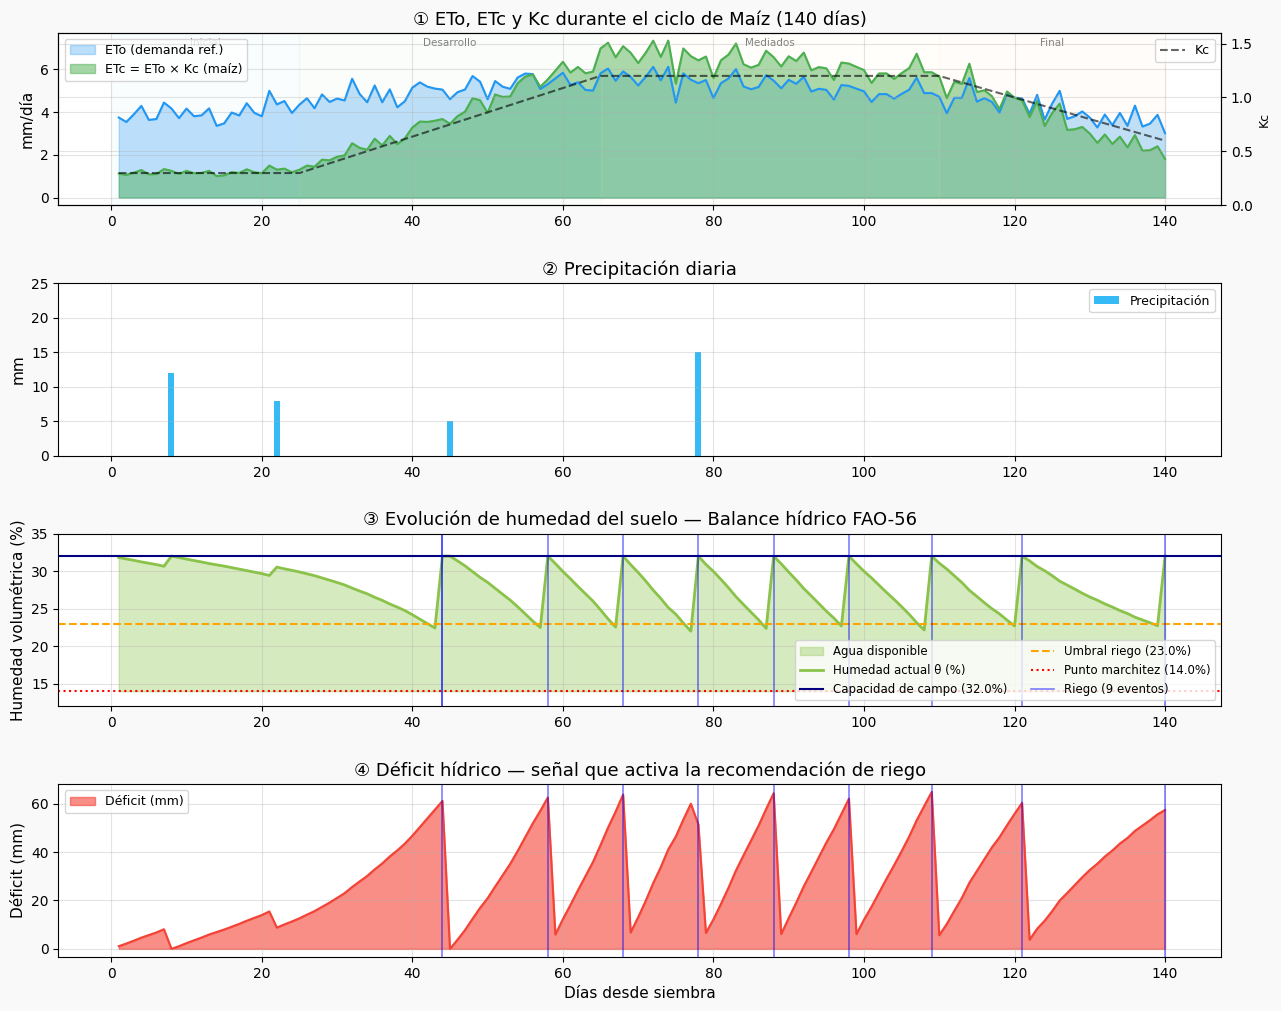

ETc acumulada ciclo:  584 mm (5840 m³/ha)
Número de riegos:     9


In [17]:
fig = plt.figure(figsize=(15, 12))
gs  = GridSpec(4, 1, figure=fig, hspace=0.45)

# ── Panel 1: ETo y ETc ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
kcs_ciclo = [obtener_kc('maiz', d) for d in dias]
ax1.fill_between(dias, eto_diario, alpha=0.3, color=COLORS['eto'],  label='ETo (demanda ref.)')
ax1.fill_between(dias, etc_arr,   alpha=0.5, color=COLORS['etc'],  label='ETc = ETo × Kc (maíz)')
ax1.plot(dias, eto_diario, color=COLORS['eto'], lw=1.5)
ax1.plot(dias, etc_arr,    color=COLORS['etc'], lw=1.5)
ax1_b = ax1.twinx()
ax1_b.plot(dias, kcs_ciclo, 'k--', lw=1.5, alpha=0.6, label='Kc')
ax1_b.set_ylabel('Kc', fontsize=9)
ax1_b.set_ylim(0, 1.6)
ax1.set_ylabel('mm/día')
ax1.set_title('① ETo, ETc y Kc durante el ciclo de Maíz (140 días)')
ax1.legend(loc='upper left', fontsize=9)
ax1_b.legend(loc='upper right', fontsize=9)

# Zonas fenológicas
info = KC_TABLE['maiz']
d_ini, d_des, d_med, d_fin = info['duracion_etapas']
limites_e = [0, d_ini, d_ini+d_des, d_ini+d_des+d_med, dias_ciclo]
for i, (a, b) in enumerate(zip(limites_e, limites_e[1:])):
    ax1.axvspan(a, b, alpha=0.07, color=ETAPAS_COLORES[i])
    ax1.text((a+b)/2, ax1.get_ylim()[1]*0.92, ETAPAS_NOMBRES[i],
             ha='center', fontsize=7.5, color='gray')

# ── Panel 2: Lluvia ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(dias, lluvia, color=COLORS['lluvia'], alpha=0.8, label='Precipitación')
ax2.set_ylabel('mm')
ax2.set_title('② Precipitación diaria')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 25)

# ── Panel 3: Humedad del suelo ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.fill_between(dias, PMP, humedad, alpha=0.35, color=COLORS['humedad'], label='Agua disponible')
ax3.plot(dias, humedad, color=COLORS['humedad'], lw=2, label='Humedad actual θ (%)')
ax3.axhline(CC,     color='navy',   lw=1.5, ls='-',  label=f'Capacidad de campo ({CC}%)')
ax3.axhline(umbral, color='orange', lw=1.5, ls='--', label=f'Umbral riego ({umbral:.1f}%)')
ax3.axhline(PMP,    color='red',    lw=1.5, ls=':',  label=f'Punto marchitez ({PMP}%)')

for r in riegos:
    ax3.axvline(r+1, color='blue', alpha=0.5, lw=1.2)
ax3.axvline(riegos[0]+1, color='blue', alpha=0.5, lw=1.2, label=f'Riego ({len(riegos)} eventos)')

ax3.set_ylabel('Humedad volumétrica (%)')
ax3.set_title('③ Evolución de humedad del suelo — Balance hídrico FAO-56')
ax3.legend(fontsize=8.5, loc='lower right', ncol=2)
ax3.set_ylim(PMP - 2, CC + 3)

# ── Panel 4: Déficit acumulado ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.fill_between(dias, deficit_arr, color=COLORS['deficit'], alpha=0.6, label='Déficit (mm)')
ax4.plot(dias, deficit_arr, color=COLORS['deficit'], lw=1.5)

for r in riegos:
    ax4.axvline(r+1, color='blue', alpha=0.5, lw=1.2)

ax4.set_xlabel('Días desde siembra')
ax4.set_ylabel('Déficit (mm)')
ax4.set_title('④ Déficit hídrico — señal que activa la recomendación de riego')
ax4.legend(fontsize=9)

plt.savefig('fao56_balance_maiz.png', dpi=150, bbox_inches='tight')
plt.show()

total_etc  = etc_arr.sum()
vol_riego  = sum([
    calcular_balance_hidrico(0, 0, 14.0, CC, PMP, Zr)['lamina_bruta_mm'] * 10
    for _ in riegos
])
print(f"ETc acumulada ciclo:  {total_etc:.0f} mm ({total_etc*10:.0f} m³/ha)")
print(f"Número de riegos:     {len(riegos)}")

---
## 6. Lámina de riego y costo energético (CFE 9-CU)

Tarifa baseline del proyecto: **$1.68 MXN/m³** (bombeo 80m, tarifa CFE agrícola).

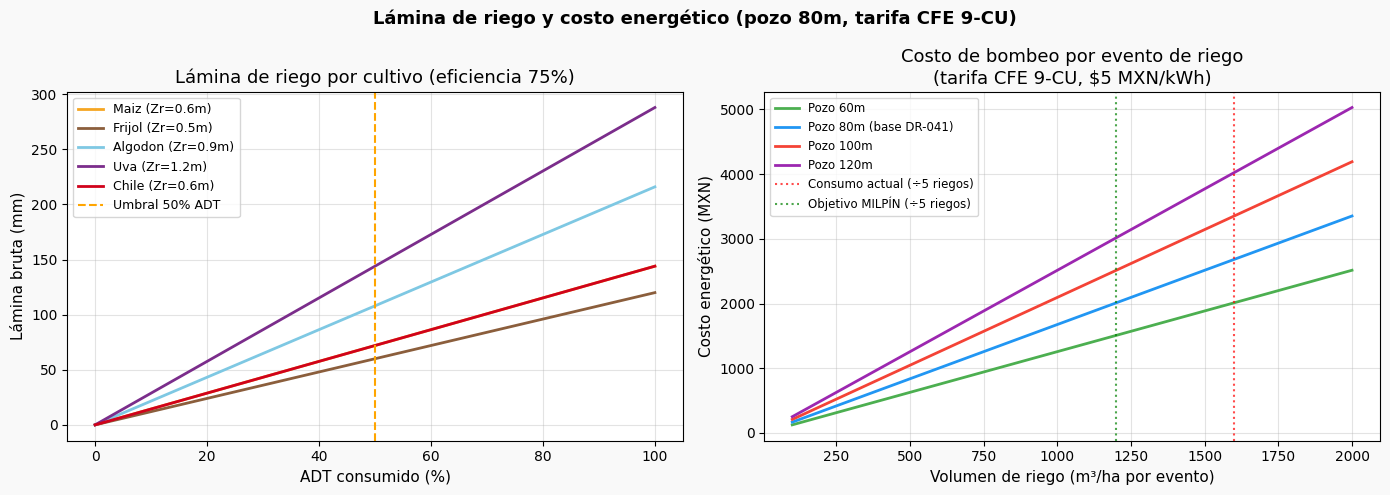

In [18]:
# ─── Variación de lámina de riego por cultivo y suelo ─────────────────────────

# Escenarios de humedad inicial (% ADT consumido)
pcts_adt = np.arange(0, 1.01, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lámina de riego y costo energético (pozo 80m, tarifa CFE 9-CU)',
             fontsize=13, weight='bold')

# Panel izquierdo — Lámina bruta por cultivo (profundidad raíces diferente)
ax = axes[0]
profundidades = {'maiz': 0.60, 'frijol': 0.50, 'algodon': 0.90, 'uva': 1.20, 'chile': 0.60}

for cultivo, Zr_c in profundidades.items():
    laminas = []
    for pct in pcts_adt:
        humedad_act = CC - pct * (CC - PMP)  # humedad según % ADT consumido
        res = calcular_balance_hidrico(
            etc_mm=0, precipitacion_mm=0,
            humedad_actual_pct=humedad_act,
            capacidad_campo_pct=CC,
            punto_marchitez_pct=PMP,
            profundidad_raiz_m=Zr_c,
        )
        laminas.append(res['lamina_bruta_mm'])
    ax.plot(pcts_adt * 100, laminas, color=COLORS[cultivo], lw=2,
            label=f'{cultivo.capitalize()} (Zr={Zr_c}m)')

ax.axvline(50, color='orange', ls='--', lw=1.5, label='Umbral 50% ADT')
ax.set_xlabel('ADT consumido (%)')
ax.set_ylabel('Lámina bruta (mm)')
ax.set_title('Lámina de riego por cultivo (eficiencia 75%)')
ax.legend(fontsize=9)

# Panel derecho — Costo MXN por riego en función del volumen
ax2 = axes[1]
volumenes = np.arange(100, 2001, 50)  # m³/ha

for prof, label, color in [
    (60,  'Pozo 60m',  '#4CAF50'),
    (80,  'Pozo 80m (base DR-041)', '#2196F3'),
    (100, 'Pozo 100m', '#F44336'),
    (120, 'Pozo 120m', '#9C27B0'),
]:
    costos = [calcular_costo_riego(v, profundidad_pozo_m=prof)['costo_pesos'] for v in volumenes]
    ax2.plot(volumenes, costos, lw=2, label=label, color=color)

# Marcar objetivo MILPÍN: reducir de 8000 a 6000 m³/ha/ciclo
ax2.axvline(8000/5, color='red',   ls=':', alpha=0.7, label='Consumo actual (÷5 riegos)')
ax2.axvline(6000/5, color='green', ls=':', alpha=0.7, label='Objetivo MILPÍN (÷5 riegos)')

ax2.set_xlabel('Volumen de riego (m³/ha por evento)')
ax2.set_ylabel('Costo energético (MXN)')
ax2.set_title('Costo de bombeo por evento de riego\n(tarifa CFE 9-CU, $5 MXN/kWh)')
ax2.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('fao56_costo_lamina.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Impacto del KPI central: 8,000 → 6,000 m³/ha/ciclo

MILPÍN busca un ahorro del 25% en consumo de agua por ciclo agrícola.

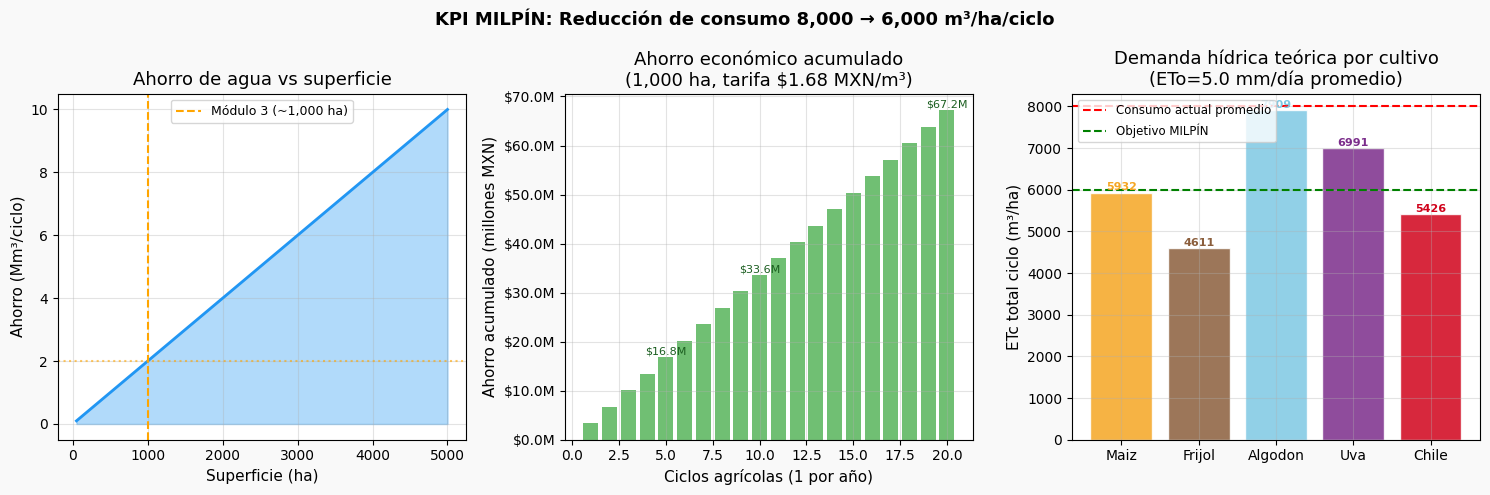

Ahorro anual (1,000 ha, $1.68/m³): $3.36 millones MXN/ciclo
Ahorro a 10 años:                  $33.6 millones MXN


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('KPI MILPÍN: Reducción de consumo 8,000 → 6,000 m³/ha/ciclo',
             fontsize=13, weight='bold')

# ─── 7a. Ahorro de agua por superficie ────────────────────────────────────────
ax = axes[0]
hectareas = np.arange(50, 5001, 50)
ahorro_m3 = hectareas * (8000 - 6000)
ahorro_Mm3 = ahorro_m3 / 1e6

ax.fill_between(hectareas, ahorro_Mm3, alpha=0.35, color='#2196F3')
ax.plot(hectareas, ahorro_Mm3, color='#2196F3', lw=2)
ax.axvline(1000, color='orange', ls='--', lw=1.5, label='Módulo 3 (~1,000 ha)')
ax.axhline(ahorro_Mm3[hectareas == 1000][0] if 1000 in hectareas else 2.0,
           color='orange', ls=':', alpha=0.6)
ax.set_xlabel('Superficie (ha)')
ax.set_ylabel('Ahorro (Mm³/ciclo)')
ax.set_title('Ahorro de agua vs superficie')
ax.legend(fontsize=9)

# ─── 7b. Ahorro económico acumulado ──────────────────────────────────────────
ax2 = axes[1]
ciclos = np.arange(1, 21)
tarifa = 1.68  # MXN/m³
ahorro_anual_1000ha = 1000 * (8000 - 6000) * tarifa  # MXN/ciclo

ax2.bar(ciclos, ciclos * ahorro_anual_1000ha / 1e6, color='#4CAF50', alpha=0.8)
ax2.set_xlabel('Ciclos agrícolas (1 por año)')
ax2.set_ylabel('Ahorro acumulado (millones MXN)')
ax2.set_title('Ahorro económico acumulado\n(1,000 ha, tarifa $1.68 MXN/m³)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Anotar año 5 y 10
for ciclo in [5, 10, 20]:
    val = ciclo * ahorro_anual_1000ha / 1e6
    ax2.text(ciclo, val + 0.5, f'${val:.1f}M', ha='center', fontsize=8, color='#1B5E20')

# ─── 7c. Comparativa consumo por cultivo (actual vs optimizado) ──────────────
ax3 = axes[2]
cultivos_etcs = {}
eto_ref = 5.0  # mm/día promedio ciclo

for cultivo in cultivos:
    info = KC_TABLE[cultivo]
    ciclo_dias = sum(info['duracion_etapas'])
    etc_total_mm = sum(obtener_kc(cultivo, d) * eto_ref for d in range(1, ciclo_dias+1))
    etc_total_m3ha = etc_total_mm * 10  # 1mm = 10 m³/ha
    cultivos_etcs[cultivo] = etc_total_m3ha

x = np.arange(len(cultivos))
bars = ax3.bar(x, [cultivos_etcs[c] for c in cultivos],
               color=[COLORS[c] for c in cultivos], alpha=0.85, edgecolor='white')
ax3.axhline(8000, color='red',   ls='--', lw=1.5, label='Consumo actual promedio')
ax3.axhline(6000, color='green', ls='--', lw=1.5, label='Objetivo MILPÍN')
ax3.set_xticks(x)
ax3.set_xticklabels([c.capitalize() for c in cultivos])
ax3.set_ylabel('ETc total ciclo (m³/ha)')
ax3.set_title(f'Demanda hídrica teórica por cultivo\n(ETo={eto_ref} mm/día promedio)')
ax3.legend(fontsize=8.5)

for bar, cultivo in zip(bars, cultivos):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:.0f}', 
             ha='center', fontsize=8, weight='bold', color=COLORS[cultivo])

plt.tight_layout()
plt.savefig('fao56_kpi_impacto.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ahorro anual (1,000 ha, $1.68/m³): ${ahorro_anual_1000ha/1e6:.2f} millones MXN/ciclo")
print(f"Ahorro a 10 años:                  ${10*ahorro_anual_1000ha/1e6:.1f} millones MXN")

---
## 8. Presión de vapor de saturación — La física detrás de la humedad

$e°(T) = 0.6108 \cdot \exp\left(\frac{17.27\,T}{T + 237.3}\right)$ (FAO-56 Ec. 11)  

Esta curva es no lineal, lo que hace que el **déficit de presión de vapor** ($e_s - e_a$)  
crezca exponencialmente con la temperatura — explicando por qué el verano seco  
en Sonora dispara la evapotranspiración.

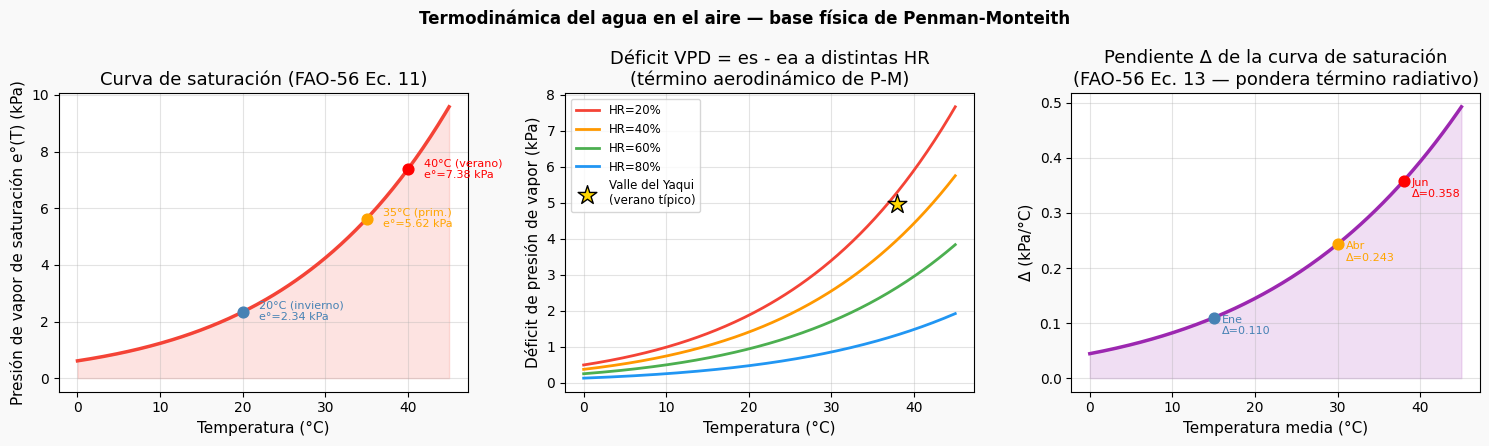

In [20]:
temps = np.linspace(0, 45, 200)
es_vals = _presion_saturacion(temps)
delta_vals = _pendiente_curva_saturacion(temps)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Termodinámica del agua en el aire — base física de Penman-Monteith',
             fontsize=12, weight='bold')

# Panel 1 — Curva de saturación
ax = axes[0]
ax.plot(temps, es_vals, color='#F44336', lw=2.5)
for T, label, color in [(20, '20°C (invierno)', 'steelblue'), (35, '35°C (prim.)', 'orange'), (40, '40°C (verano)', 'red')]:
    es = _presion_saturacion(T)
    ax.scatter([T], [es], zorder=5, s=60, color=color)
    ax.annotate(f'{label}\ne°={es:.2f} kPa', xy=(T, es), xytext=(T+2, es-0.3),
                fontsize=8, color=color)
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Presión de vapor de saturación e°(T) (kPa)')
ax.set_title('Curva de saturación (FAO-56 Ec. 11)')
ax.fill_between(temps, es_vals, alpha=0.15, color='#F44336')

# Panel 2 — Déficit de presión de vapor a distintas HR
ax2 = axes[1]
for hr, color in [(20, '#F44336'), (40, '#FF9800'), (60, '#4CAF50'), (80, '#2196F3')]:
    deficit = es_vals * (1 - hr/100)
    ax2.plot(temps, deficit, color=color, lw=2, label=f'HR={hr}%')
ax2.set_xlabel('Temperatura (°C)')
ax2.set_ylabel('Déficit de presión de vapor (kPa)')
ax2.set_title('Déficit VPD = es - ea a distintas HR\n(término aerodinámico de P-M)')
ax2.legend(fontsize=9)
# Marcar zona Valle del Yaqui en verano (T≈38°C, HR≈25%)
ax2.scatter([38], [_presion_saturacion(38) * 0.75], s=200, marker='*',
            color='gold', edgecolor='k', zorder=8, label='Valle del Yaqui\n(verano típico)')
ax2.legend(fontsize=8.5)

# Panel 3 — Pendiente de la curva Δ (Factor radiativo de P-M)
ax3 = axes[2]
ax3.plot(temps, delta_vals, color='#9C27B0', lw=2.5)
ax3.fill_between(temps, delta_vals, alpha=0.15, color='#9C27B0')
ax3.set_xlabel('Temperatura media (°C)')
ax3.set_ylabel('Δ (kPa/°C)')
ax3.set_title('Pendiente Δ de la curva de saturación\n(FAO-56 Ec. 13 — pondera término radiativo)')

# Temperaturas medias típicas del Valle del Yaqui
for T, mes, color in [(15, 'Ene', 'steelblue'), (30, 'Abr', 'orange'), (38, 'Jun', 'red')]:
    d = _pendiente_curva_saturacion(T)
    ax3.scatter([T], [d], s=60, zorder=5, color=color)
    ax3.annotate(f'{mes}\nΔ={d:.3f}', xy=(T, d), xytext=(T+1, d-0.03), fontsize=8, color=color)

plt.tight_layout()
plt.savefig('fao56_termodinamica.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Resumen: ¿Qué tan importante es FAO-56 en MILPÍN?

FAO-56 no es solo una fórmula — es la columna vertebral de cada decisión del sistema.

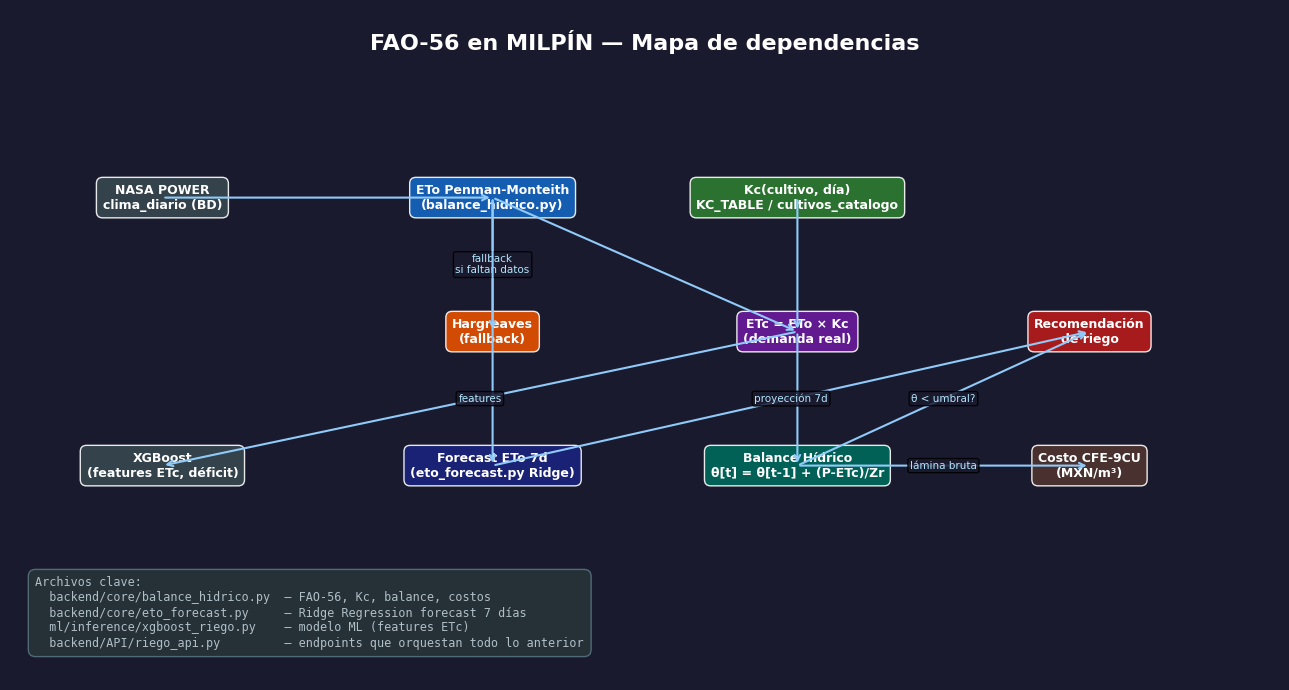

In [21]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')
fig.patch.set_facecolor('#1a1a2e')

titulo = 'FAO-56 en MILPÍN — Mapa de dependencias'
ax.text(0.5, 0.97, titulo, ha='center', va='top', fontsize=16, weight='bold',
        color='white', transform=ax.transAxes)

# Definir nodos
nodos = {
    # (x, y, texto, color_fondo, color_texto)
    'nasa':     (0.12, 0.72, 'NASA POWER\nclima_diario (BD)', '#37474F', 'white'),
    'eto':      (0.38, 0.72, 'ETo Penman-Monteith\n(balance_hidrico.py)', '#1565C0', 'white'),
    'harg':     (0.38, 0.52, 'Hargreaves\n(fallback)', '#E65100', 'white'),
    'kc':       (0.62, 0.72, 'Kc(cultivo, día)\nKC_TABLE / cultivos_catalogo', '#2E7D32', 'white'),
    'etc':      (0.62, 0.52, 'ETc = ETo × Kc\n(demanda real)', '#6A1B9A', 'white'),
    'balance':  (0.62, 0.32, 'Balance Hídrico\nθ[t] = θ[t-1] + (P-ETc)/Zr', '#00695C', 'white'),
    'reco':     (0.85, 0.52, 'Recomendación\nde riego', '#B71C1C', 'white'),
    'costo':    (0.85, 0.32, 'Costo CFE-9CU\n(MXN/m³)', '#4E342E', 'white'),
    'forecast': (0.38, 0.32, 'Forecast ETo 7d\n(eto_forecast.py Ridge)', '#1A237E', 'white'),
    'ml':       (0.12, 0.32, 'XGBoost\n(features ETc, déficit)', '#37474F', 'white'),
}

# Dibujar cajas
for key, (x, y, texto, bg, fg) in nodos.items():
    ax.text(x, y, texto, ha='center', va='center', fontsize=9,
            color=fg, weight='bold', transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=bg, edgecolor='white', alpha=0.9))

# Flechas entre nodos
conexiones = [
    ('nasa', 'eto',     ''),
    ('eto',  'harg',    'fallback\nsi faltan datos'),
    ('eto',  'etc',     ''),
    ('kc',   'etc',     ''),
    ('etc',  'balance', ''),
    ('balance', 'reco', 'θ < umbral?'),
    ('balance', 'costo','lámina bruta'),
    ('eto',  'forecast',''),
    ('forecast', 'reco', 'proyección 7d'),
    ('etc',  'ml',      'features'),
]

for n1, n2, label in conexiones:
    x1, y1 = nodos[n1][0], nodos[n1][1]
    x2, y2 = nodos[n2][0], nodos[n2][1]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#90CAF9', lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my, label, ha='center', va='center', fontsize=7.5,
                color='#B3E5FC', transform=ax.transAxes,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#1a1a2e', alpha=0.85))

# Leyenda de archivos
archivos_txt = (
    "Archivos clave:\n"
    "  backend/core/balance_hidrico.py  — FAO-56, Kc, balance, costos\n"
    "  backend/core/eto_forecast.py     — Ridge Regression forecast 7 días\n"
    "  ml/inference/xgboost_riego.py    — modelo ML (features ETc)\n"
    "  backend/API/riego_api.py         — endpoints que orquestan todo lo anterior"
)
ax.text(0.02, 0.10, archivos_txt, ha='left', va='center', fontsize=8.5,
        color='#B0BEC5', transform=ax.transAxes, family='monospace',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#263238', edgecolor='#546E7A', alpha=0.95))

plt.tight_layout()
plt.savefig('fao56_mapa_dependencias.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

In [22]:
# ─── Tabla resumen final ───────────────────────────────────────────────────────
print('=' * 70)
print('RESUMEN: Rol de FAO-56 en MILPÍN')
print('=' * 70)

rows = [
    ('Módulo',             'Función FAO-56',                         'Archivo'),
    ('─'*20,               '─'*35,                                   '─'*20),
    ('Balance hídrico',    'ETo P-M → ETc → θ[t]',                  'balance_hidrico.py'),
    ('Hargreaves fallback','ETo con solo T cuando falta HR/viento',  'balance_hidrico.py'),
    ('Forecast 7 días',    'Ridge predice ETo futuro → FAO-56 fwd',  'eto_forecast.py'),
    ('API riego',          'Orquesta: parcela + clima + FAO-56',     'riego_api.py'),
    ('API db',             'forecast_parcela() con propagar()',      'db_api.py'),
    ('ML XGBoost',         'ETc + déficit como features del modelo', 'xgboost_riego.py'),
    ('ETL NASA POWER',     'calcular_eto_pm_serie() vectorizada',    'nasa_power_etl.py'),
]

for row in rows:
    print(f'  {row[0]:<22} {row[1]:<37} {row[2]}')

print()
print('KPI central MILPÍN:')
for cultivo in cultivos:
    info = KC_TABLE[cultivo]
    ciclo = sum(info['duracion_etapas'])
    etc_mm = sum(obtener_kc(cultivo, d) * 5.0 for d in range(1, ciclo+1))
    print(f'  {cultivo.capitalize():<10}  ciclo {ciclo:>3}d  ETc estimada {etc_mm*10:>6.0f} m³/ha '
          f'  Kc_med={info["kc"][1]}')

print()
print(f'  Ahorro objetivo (25%): 8,000 → 6,000 m³/ha/ciclo')
print(f'  Tarifa base:           $1.68 MXN/m³  (CFE 9-CU, bombeo 80m)')
print(f'  Ahorro económico:      ${1000*2000*1.68/1e6:.2f}M MXN/ciclo/1000ha')
print('=' * 70)

RESUMEN: Rol de FAO-56 en MILPÍN
  Módulo                 Función FAO-56                        Archivo
  ────────────────────   ───────────────────────────────────   ────────────────────
  Balance hídrico        ETo P-M → ETc → θ[t]                  balance_hidrico.py
  Hargreaves fallback    ETo con solo T cuando falta HR/viento balance_hidrico.py
  Forecast 7 días        Ridge predice ETo futuro → FAO-56 fwd eto_forecast.py
  API riego              Orquesta: parcela + clima + FAO-56    riego_api.py
  API db                 forecast_parcela() con propagar()     db_api.py
  ML XGBoost             ETc + déficit como features del modelo xgboost_riego.py
  ETL NASA POWER         calcular_eto_pm_serie() vectorizada   nasa_power_etl.py

KPI central MILPÍN:
  Maiz        ciclo 140d  ETc estimada   5932 m³/ha   Kc_med=1.2
  Frijol      ciclo 110d  ETc estimada   4611 m³/ha   Kc_med=1.15
  Algodon     ciclo 180d  ETc estimada   7909 m³/ha   Kc_med=1.2
  Uva         ciclo 215d  ETc estimada   